In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import scipy
from scipy.interpolate import UnivariateSpline

In [23]:
darcy = pd.read_csv('P829_Geoloop_63026_72726.csv')

In [24]:
darcy

,TIMESTAMP,Hour,Minute,Well_ID,Project_ID,GeoloopFromBldgT,GeoloopToBldgT,GeoloopGPM,VFDFreq,Applied filters:
0,6/30/2026 0:01,0,1,Well01,P829,58.7,57.1,49.7481,0.0,Well_ID is Well01
1,6/30/2026 0:02,0,2,Well01,P829,59.1,56.9,49.7481,0.0,TIMESTAMP is on or after 6/30/2026 12:00:00 AM...
2,6/30/2026 0:03,0,3,Well01,P829,59.3,56.9,49.7481,0.0,Hour is less than or equal to 24
3,6/30/2026 0:04,0,4,Well01,P829,59.5,57.0,49.7481,0.0,Project_ID is P829
4,6/30/2026 0:05,0,5,Well01,P829,59.7,57.2,49.7481,0.0,Project_ID is P829
...,...,...,...,...,...,...,...,...,...,...
40227,7/27/2026 23:55,23,55,Well01,P829,54.3,52.9,138.0982,0.0,NaN
40228,7/27/2026 23:56,23,56,Well01,P829,57.5,55.7,136.2091,0.0,NaN
40229,7/27/2026 23:57,23,57,Well01,P829,56.0,54.1,134.3199,0.0,NaN
40230,7/27/2026 23:58,23,58,Well01,P829,56.1,56.2,132.3678,0.0,NaN


In [25]:
darcy['ExitTempC'] = ((darcy['GeoloopToBldgT'] - 32) * 5/9)

In [26]:
darcy['ReturnTempC'] = ((darcy['GeoloopFromBldgT'] - 32) * 5/9)

In [27]:
darcy['TIMESTAMP'] = pd.to_datetime(darcy['TIMESTAMP'])

In [35]:
darcy['DateString'] = darcy.TIMESTAMP.dt.strftime('%B %Y')

In [36]:
darcy.head()

,TIMESTAMP,Hour,Minute,Well_ID,Project_ID,GeoloopFromBldgT,GeoloopToBldgT,GeoloopGPM,VFDFreq,Applied filters:,ExitTempC,ReturnTempC,DateString
0,2026-06-30 00:01:00,0,1,Well01,P829,58.7,57.1,49.7481,0.0,Well_ID is Well01,13.944444,14.833333,June 2026
1,2026-06-30 00:02:00,0,2,Well01,P829,59.1,56.9,49.7481,0.0,TIMESTAMP is on or after 6/30/2026 12:00:00 AM...,13.833333,15.055556,June 2026
2,2026-06-30 00:03:00,0,3,Well01,P829,59.3,56.9,49.7481,0.0,Hour is less than or equal to 24,13.833333,15.166667,June 2026
3,2026-06-30 00:04:00,0,4,Well01,P829,59.5,57.0,49.7481,0.0,Project_ID is P829,13.888889,15.277778,June 2026
4,2026-06-30 00:05:00,0,5,Well01,P829,59.7,57.2,49.7481,0.0,Project_ID is P829,14.000000,15.388889,June 2026


In [51]:
# spl = UnivariateSpline(darcy.TIMESTAMP, darcy.ExitTempC)

In [52]:
# make_splrep(darcy.TIMESTAMP, darcy.ExitTempC,)

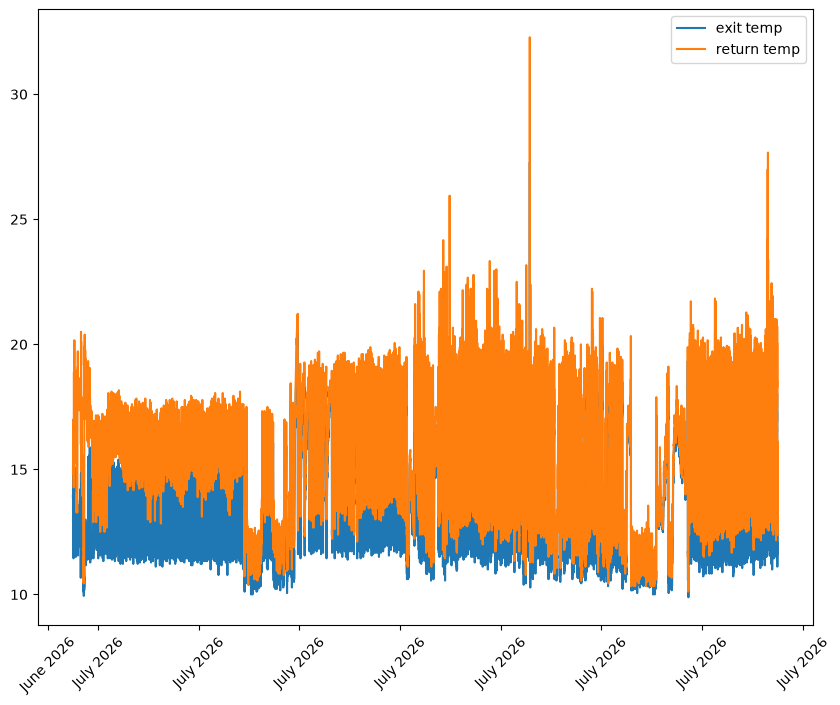

In [58]:
fig, ax = plt.subplots(figsize = (10, 8))

ax.plot(darcy.TIMESTAMP, darcy.ExitTempC, label = 'exit temp')
ax.plot(darcy.TIMESTAMP, darcy.ReturnTempC, label = 'return temp')
# ax.plot(darcy.TIMESTAMP, darcy.GeoloopGPM, label = 'pumping rate (gpm)')
# ax.plot(xs, spl(xs), 'g', lw=3)

dates = mdates.DateFormatter('%B %Y')
ax.xaxis.set_major_formatter(dates)
plt.xticks(rotation=45)
plt.legend()

plt.show()